In [2]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import iterate
importlib.reload(iterate)
from iterate import find_super_stable, iterate_postrans

np.set_printoptions(suppress=True)

/home/damon/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


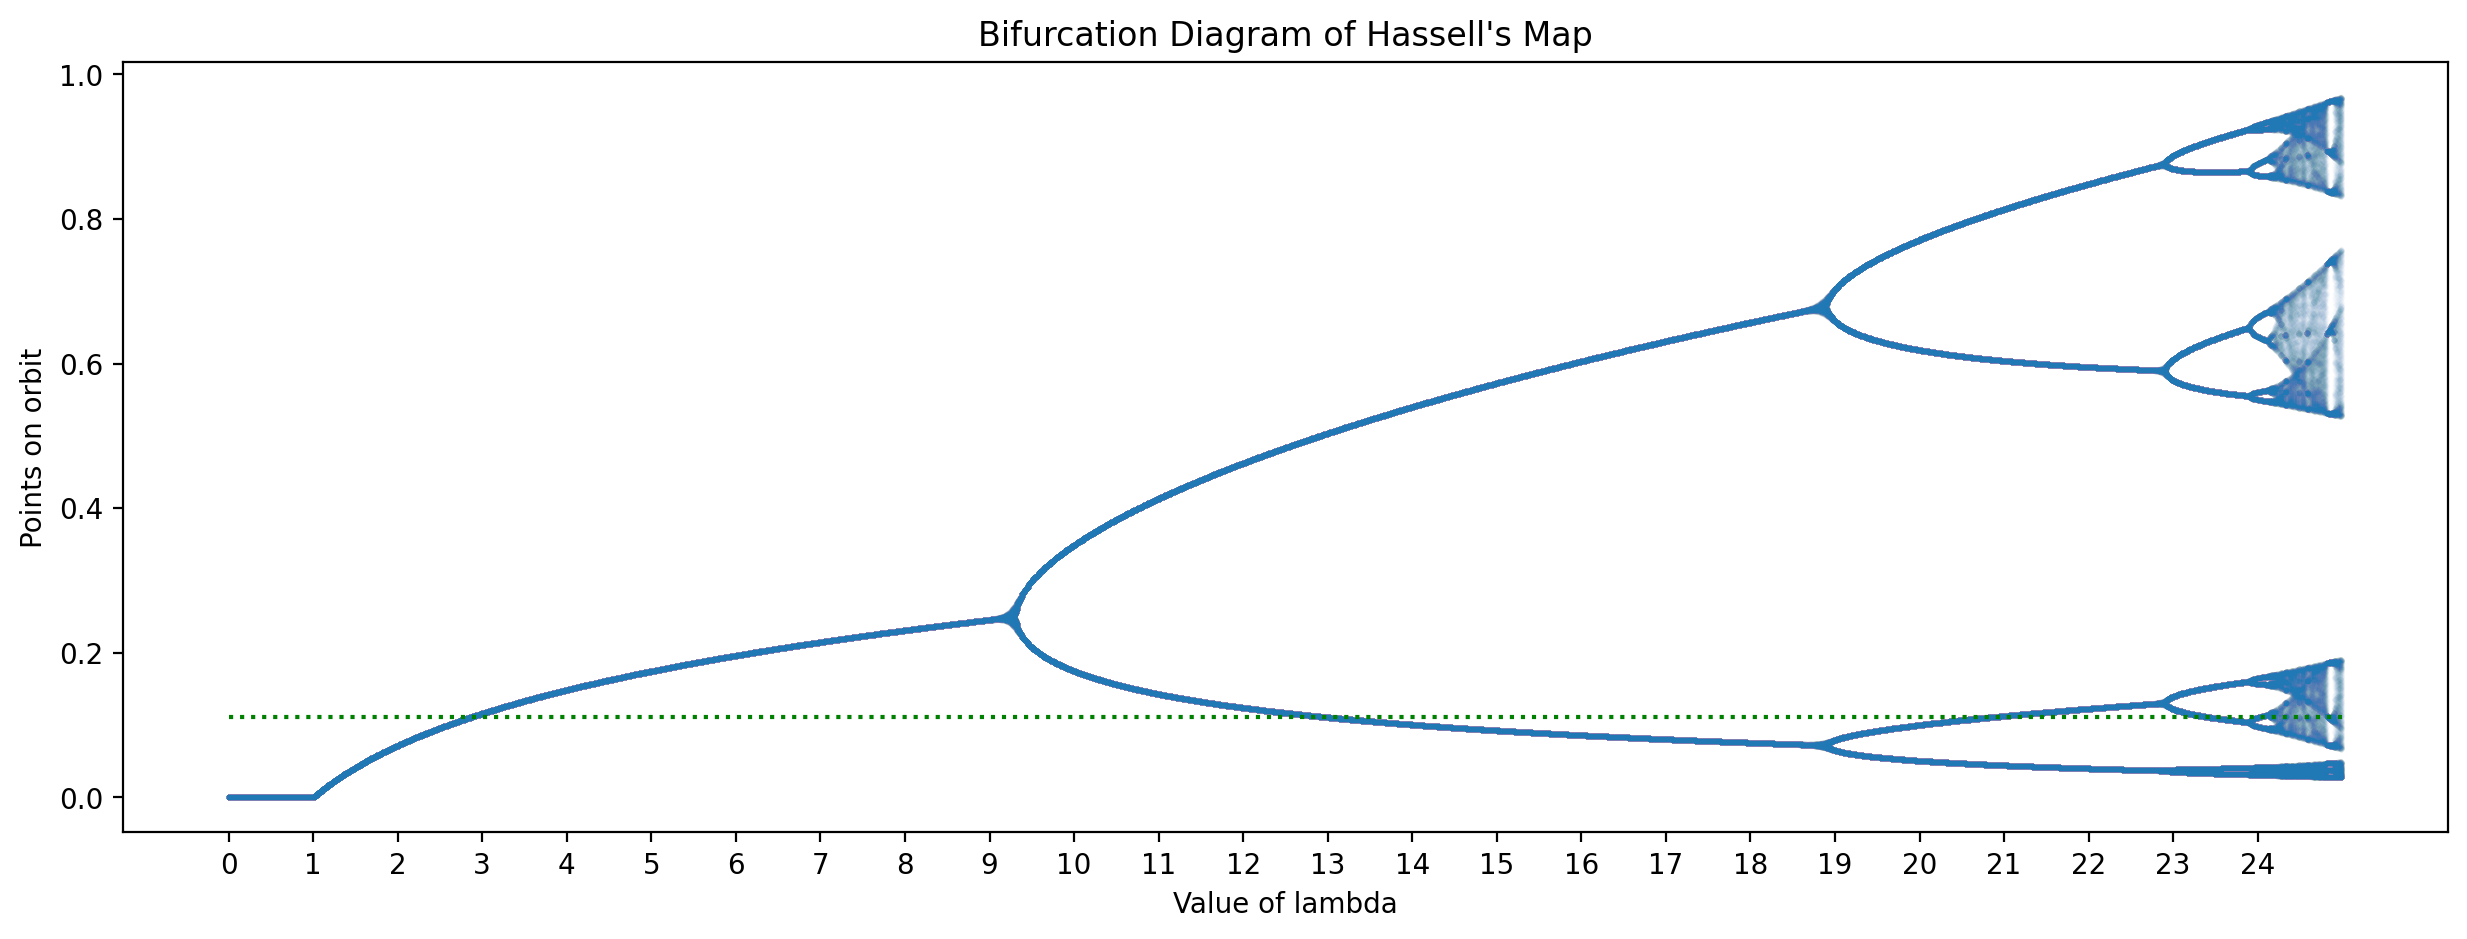

In [9]:
xs = []
ys = []
for l in np.arange(0, 25, 0.01):
    iterates = 1000
    xs.extend([l] * iterates)
    ys.extend(iterate_postrans(l, 1.0 / 9.0, iterates)[1])

plt.figure(figsize=(15, 5), dpi=200)
sns.scatterplot(x=xs, y=ys, alpha=0.01, s=5)
plt.title("Bifurcation Diagram of Hassell's Map")
plt.xticks(np.arange(0, 25, 1))
plt.xlabel("Value of lambda")
plt.ylabel("Points on orbit")
plt.hlines(1/9, 0, 25, colors="green", linestyles="dotted")
plt.show()

In [3]:
find_super_stable(2, 12.99)

/home/damon/Documents/C455/c455-project/iterate.py:72: RuntimeWarning: overflow encountered in power
  xp = x / np.pow((x + 1), BETA)
/home/damon/Documents/C455/c455-project/iterate.py:7: RuntimeWarning: overflow encountered in scalar multiply
  return l * x / np.pow(1 + x, BETA)
/home/damon/Documents/C455/c455-project/iterate.py:7: RuntimeWarning: overflow encountered in power
  return l * x / np.pow(1 + x, BETA)
/home/damon/Documents/C455/c455-project/iterate.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return l * x / np.pow(1 + x, BETA)


RuntimeError: l has become NaN or Inf at 11 iterations

In [23]:
sks = [2.86, 12.99, find_super_stable(3, 20.89)[1]]
f_consts = [4]
print(f"S3 = {sks[-1]}, f3 = {f_consts[-1]})")

for i in range(4, 11):
    diff = sks[-1] - sks[-2]
    new_guess = sks[-1] + (diff) / f_consts[-1]
    sks.append(find_super_stable(i, new_guess)[1])
    f_consts.append((sks[-3] - sks[-2]) / (sks[-2] - sks[-1]))
    print(f"S{i} = {sks[-1]}, diff={diff}, f{i} = {f_consts[-1]}")

figenbaum_pt = sks[-1] + (sks[-1] - sks[-2]) / (f_consts[-1] - 1)
print(f"Accumulation point: {figenbaum_pt}")

RuntimeError: Failed to find super stable point (last guess: 22.08178050866297)